In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Solve the Lorenz model

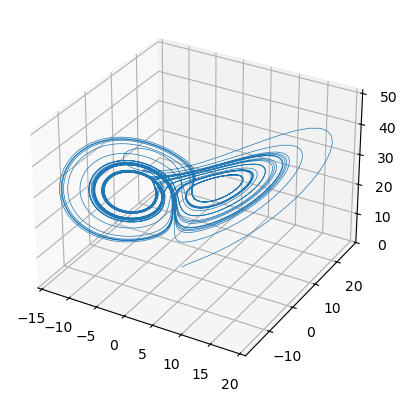

In [ ]:
# Define the Lorenz model based on the given functions
# y = (y1, y2, y3)
# dy1/dt = a(y2 - y1)
# dy2/dt = (b - y3)y1 - y2
# dy3/dt = y1*y2 - c*y3   (c = 1 here)
def lorenz(t, y, a, b):
    y1, y2, y3 = y
    return [a*(y2-y1), (b-y3)*y1 - y2, y1*y2 - y3]

# Solve the model using scipy
# Time interval: 0-60
# y1=y2=y3=1 at t=0
# a = 10, b = 28 (Lorenz used these in his original 1963 paper. Here c = 1 instead of Lorenz's 8/3)
# Largest time step the solver may take (small so that it is accurate): 0.01
sol = solve_ivp(lorenz, (0, 60), [1, 1, 1], args=(10, 28), max_step=0.01)

# Plot out the results in 3d with y1, y2, y3 as axes
ax = plt.figure().add_subplot(projection='3d')
ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=0.5)
plt.show()

The orbit never settles or repeats, so these parameters are chaotic.

# Finding the chaotic region
- Same as figures 4.4–4.5 in the book, I identify chaos using the phase-space plots.
- If the orbit settles onto a point or closes, the motion is regular. If it never repeats, the motion is chaotic.
- I skip the first 20 time units so only the long-time behaviour is shown.

In [9]:
# Time interval: 0-60
# y1=y2=y3=1 at t=0
# Largest time step the solver may take (small so that it is accurate): 0.01

def solve(a, b):
    return solve_ivp(lorenz, (0, 60), [1, 1, 1], args=(a, b), max_step=0.01)

First I fix a = 10 and vary b.

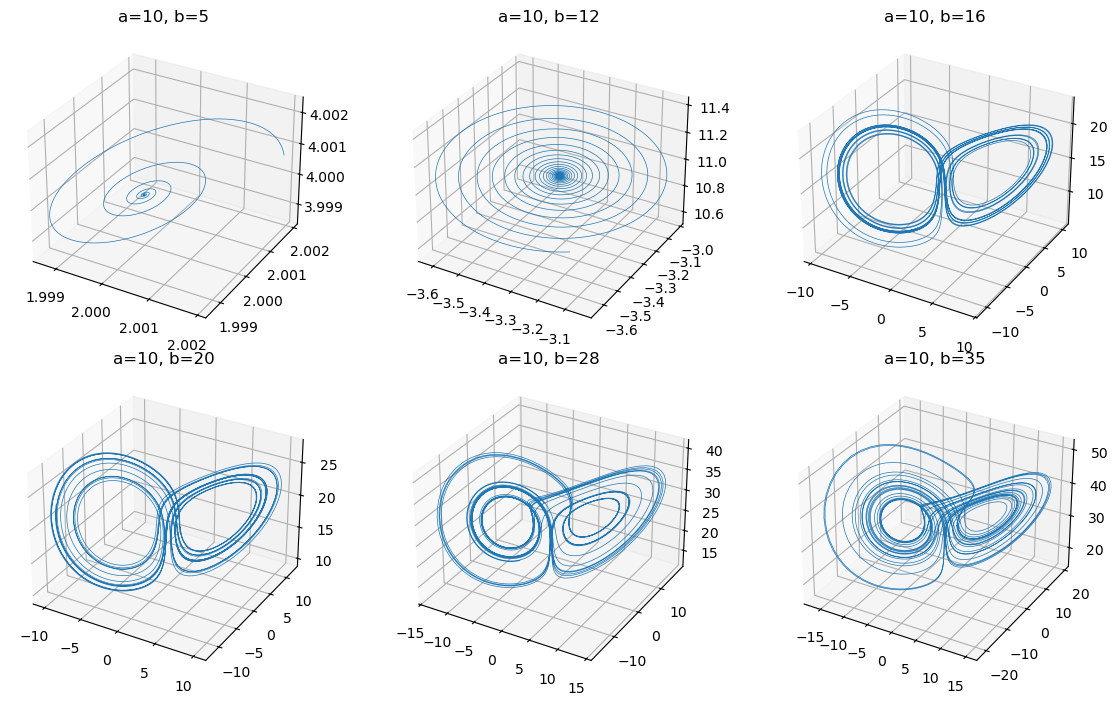

In [11]:
# fix a=10, vary b, and look at each orbit
a = 10
fig, axes = plt.subplots(2, 3, figsize=(12, 7), subplot_kw={'projection': '3d'})
for ax, b in zip(axes.flat, [5, 12, 16, 20, 28, 35]):
    sol = solve(a, b)
    keep = sol.t > 20  # skip the transient
    ax.plot(sol.y[0][keep], sol.y[1][keep], sol.y[2][keep], lw=0.5)  # y1, y2, y3
    ax.set_title(f"a={a}, b={b}")
plt.tight_layout(); plt.show()

For b = 5 and b = 12 the orbit spirals into a fixed point, so there is no chaos.
From b = 16 upwards the orbit becomes the irregular butterfly shape, so it is chaotic. 
Therefore, the onset lies between b = 12 and b = 16.

Next I fix b = 28 and vary a.

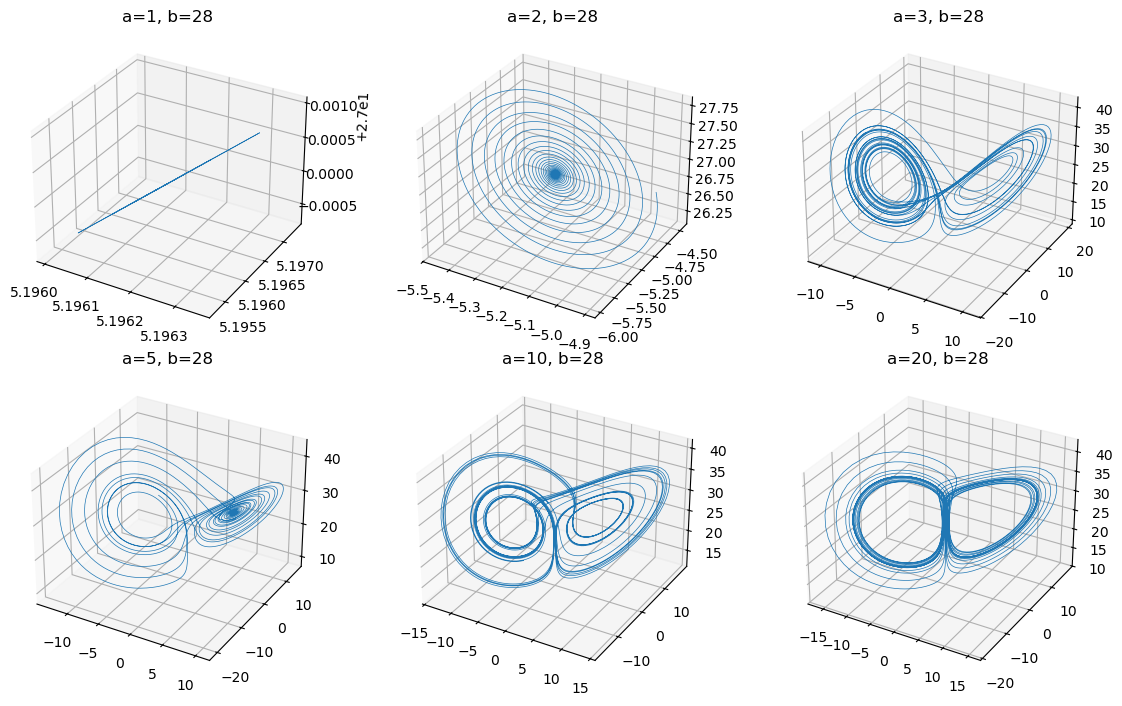

In [12]:
# fix b=28, vary a
b = 28
fig, axes = plt.subplots(2, 3, figsize=(12, 7), subplot_kw={'projection': '3d'})
for ax, a in zip(axes.flat, [1, 2, 3, 5, 10, 20]):
    sol = solve(a, b)
    keep = sol.t > 20  # skip the transient
    ax.plot(sol.y[0][keep], sol.y[1][keep], sol.y[2][keep], lw=0.5)  # y1, y2, y3
    ax.set_title(f"a={a}, b={b}")
plt.tight_layout(); plt.show()

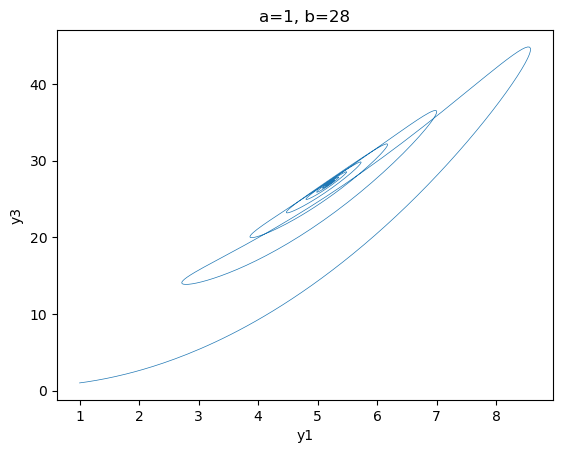

In [ ]:
# We cannot see clearly a=1 so we would need additional plot
# 2D plot for a=1, b=28: the orbit spirals into a fixed point
sol = solve(1, 28)
fig, ax = plt.subplots()
ax.plot(sol.y[0], sol.y[2], lw=0.5)  # full run so the spiral is visible
ax.set_xlabel("y1"); ax.set_ylabel("y3")
ax.set_title("a=1, b=28")
plt.show()

For a = 1 and a = 2 the orbit settles onto a fixed point. From a = 3 upwards it is chaotic.

# Conclusion
With c = 1, the system is chaotic for a above roughly 2-3 and b above roughly 14–16.
For small b, or for a <= 2, the orbit always settles onto a fixed point.